## **Подготовка окружения**

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство для вычислений: cpu


## **Физические параметры и аналитическое решение**

In [ ]:
# Параметры RLC-контура
R = 0.4       # Сопротивление, Ом
L = 1.0       # Индуктивность, Гн
C = 0.1       # Емкость, Ф
Q0 = 1.0      # Начальный заряд, Кл
I0 = 0.0      # Начальный ток, А

# Коэффициенты затухающих колебаний
gamma = R / (2 * L)
omega_0_sq = 1 / (L * C)
omega_d = np.sqrt(omega_0_sq - gamma**2)
print(f"gamma = {gamma}, omega_d = {omega_d:.4f}")

def exact_solution(t):
    """Аналитическое решение для заряда в RLC-контуре"""
    return Q0 * np.exp(-gamma * t) * (np.cos(omega_d * t) + (gamma / omega_d) * np.sin(omega_d * t))

Физические параметры контура: gamma = 0.2, omega_d = 3.1559


## **Архитектура нейронной сети**

In [ ]:
class Sine(nn.Module):
    def forward(self, x):
        return torch.sin(x)

class PINN(nn.Module):
    def __init__(self, t_physics_max=9.0):
        super().__init__()
        self.t_max = t_physics_max
        # SIREN-подобная архитектура с синусоидальной активацией
        self.net = nn.Sequential(
            nn.Linear(1, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 2)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.uniform_(m.weight, -1e-2, 1e-2)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        t_norm = t / self.t_max
        
        # Сеть предсказывает амплитуду и фазовый сдвиг
        params = self.net(t_norm)
        A_pred = params[:, 0:1]
        phi_pred = params[:, 1:2]

        # Физический анзац: Q0 * exp(-γt) * (1 + (1-exp(-t²)) * A * cos(ωt + φ))
        # Гарантирует граничные условия: q(0) = Q0
        decay = torch.exp(-gamma * t)
        harmonic = torch.cos(omega_d * t + phi_pred)
        q_pred = Q0 * decay * (1.0 + (1.0 - torch.exp(-t**2)) * A_pred * harmonic)

        return q_pred

## **Вычисление производных**

In [ ]:
def compute_derivatives(q, t):
    """Вычисляет dq/dt и d²q/dt² через автоматическое дифференцирование"""
    dq_dt = torch.autograd.grad(
        outputs=q,
        inputs=t,
        grad_outputs=torch.ones_like(q),
        create_graph=True,
        retain_graph=True
    )[0]

    d2q_dt2 = torch.autograd.grad(
        outputs=dq_dt,
        inputs=t,
        grad_outputs=torch.ones_like(dq_dt),
        create_graph=True,
        retain_graph=True
    )[0]

    return dq_dt, d2q_dt2

## **Подготовка данных**

In [ ]:
t_max = 6.0  # Верхняя граница визуализации обучающей зоны

# Фиксируем физический интервал для учета уравнения (PDE loss)
t_physics_max = 9.0

# Точки для вычисления остатка уравнения (physics-informed loss)
t_train = torch.linspace(0, t_physics_max, 2000).view(-1, 1).to(device).requires_grad_(True)
t_val = (torch.rand(500, 1) * t_physics_max).to(device).requires_grad_(True)

# Небольшой набор точек с точным решением (data loss)
n_data = 50
t_data = (torch.rand(n_data, 1) * t_physics_max).to(device)
q_data = torch.tensor(exact_solution(t_data.cpu().numpy()), dtype=torch.float32, device=device).reshape(-1,1)

## **Обучение модели**

In [ ]:
model = PINN(t_physics_max=t_physics_max).to(device)

history = {
    'epoch': [], 'train_phys_loss': [], 'val_phys_loss': [], 'test_rmse': []
}

loss_history_total = []
loss_history_ic = []
loss_history_physics = []

t_test_np = np.linspace(0, t_max, 500)
q_test_exact = exact_solution(t_test_np)

def get_physics_residual(t):
    """Остаток дифференциального уравнения: L*q'' + R*q' + (1/C)*q = 0"""
    q = model(t)
    dq_dt, d2q_dt2 = compute_derivatives(q, t)
    return L * d2q_dt2 + R * dq_dt + (1.0 / C) * q

def record_metrics(current_step):
    global q_test_exact
    model.eval()
    with torch.no_grad():
        t_test_tensor_internal = torch.tensor(t_test_np, dtype=torch.float32).view(-1, 1).to(device)
        q_pred_test = model(t_test_tensor_internal).cpu().numpy().flatten()
    model.train()

    loss_p_train = torch.mean(get_physics_residual(t_train) ** 2).item()
    loss_p_val = torch.mean(get_physics_residual(t_val) ** 2).item()

    q_pred_test = q_pred_test.flatten()
    q_test_exact = q_test_exact.flatten()
    rmse = np.sqrt(np.mean((q_pred_test - q_test_exact) ** 2))

    history['epoch'].append(current_step)
    history['train_phys_loss'].append(loss_p_train)
    history['val_phys_loss'].append(loss_p_val)
    history['test_rmse'].append(rmse)
    return loss_p_train, loss_p_val, rmse

# Этап 1: Adam оптимизатор
adam_epochs = 2000
optimizer_adam = torch.optim.Adam(model.parameters(), lr=0.002)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_adam, patience=500, factor=0.5)

print(">>> Этап 1: Adam оптимизация...")
for epoch in range(1, adam_epochs + 1):
    optimizer_adam.zero_grad()
    loss_phys = torch.mean(get_physics_residual(t_train) ** 2)
    q_pred_data = model(t_data)
    loss_data = torch.mean((q_pred_data - q_data) ** 2)
    loss_total = loss_phys + 10.0 * loss_data
    loss_total.backward()
    optimizer_adam.step()
    scheduler.step(loss_total)

    loss_history_physics.append(loss_phys.item())
    loss_history_ic.append(0.0)
    loss_history_total.append(loss_total.item())

    if epoch % 500 == 0 or epoch == 1:
        lp_train, lp_val, test_rmse = record_metrics(epoch)
        print(f"Эпоха: {epoch:4d} | Train Loss: {lp_train:.6f} | Val Loss: {lp_val:.6f} | RMSE: {test_rmse:.6e}")

rmse_after_adam = history['test_rmse'][-1]

# Этап 2: L-BFGS для финальной полировки
lbfgs_iters = 2000
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=lbfgs_iters, history_size=100, line_search_fn="strong_wolfe")

print("\n>>> Этап 2: L-BFGS полировка...")
iter_tracker = [0]

def closure():
    optimizer_lbfgs.zero_grad()
    loss_phys = torch.mean(get_physics_residual(t_train) ** 2)
    q_pred_data = model(t_data)
    loss_data = torch.mean((q_pred_data - q_data) ** 2)
    loss_total = loss_phys + 10.0 * loss_data
    loss_total.backward()

    loss_history_physics.append(loss_phys.item())
    loss_history_ic.append(0.0)
    loss_history_total.append(loss_total.item())

    if iter_tracker[0] % 20 == 0:
        lp_train, lp_val, test_rmse = record_metrics(adam_epochs + iter_tracker[0])
        print(f"L-BFGS: {iter_tracker[0]:3d} | Train Loss: {lp_train:.6f} | RMSE: {test_rmse:.6e}")

    iter_tracker[0] += 1
    return loss_total

optimizer_lbfgs.step(closure)
print("Обучение завершено!\n")

>>> Запуск ЭТАПА 1: Оптимизация через Adam...
Эпоха:    1 | Train Phys Loss: 26.809359 | Val Phys Loss: 28.572390 | Test RMSE: 7.421040e-01
Эпоха:  500 | Train Phys Loss: 0.024789 | Val Phys Loss: 0.026933 | Test RMSE: 2.238840e-02
Эпоха: 1000 | Train Phys Loss: 0.018548 | Val Phys Loss: 0.021652 | Test RMSE: 2.256275e-02
Эпоха: 1500 | Train Phys Loss: 0.008160 | Val Phys Loss: 0.009503 | Test RMSE: 1.979767e-02
Эпоха: 2000 | Train Phys Loss: 0.002570 | Val Phys Loss: 0.002771 | Test RMSE: 1.825608e-02

>>> Запуск ЭТАПА 2: Точная полировка через L-BFGS...
L-BFGS Итерация:   0 | Train Phys Loss: 0.002570 | Test RMSE: 1.825608e-02
L-BFGS Итерация:  20 | Train Phys Loss: 0.001765 | Test RMSE: 1.834425e-02
L-BFGS Итерация:  40 | Train Phys Loss: 0.001679 | Test RMSE: 1.745710e-02
L-BFGS Итерация:  60 | Train Phys Loss: 0.001153 | Test RMSE: 1.754065e-02
L-BFGS Итерация:  80 | Train Phys Loss: 0.001104 | Test RMSE: 1.752182e-02
L-BFGS Итерация: 100 | Train Phys Loss: 0.001053 | Test RMSE: 1

## **Итоговые метрики**

In [ ]:
model.eval()
with torch.no_grad():
    t_test_tensor = torch.tensor(t_test_np, dtype=torch.float32).view(-1, 1).to(device)
    q_final_pred = model(t_test_tensor).cpu().numpy().flatten()

final_rmse = np.sqrt(np.mean((q_final_pred - q_test_exact) ** 2))
final_mae = np.mean(np.abs(q_final_pred - q_test_exact))
max_error = np.max(np.abs(q_final_pred - q_test_exact))
relative_l2 = np.linalg.norm(q_final_pred - q_test_exact) / np.linalg.norm(q_test_exact)
final_msr = history['train_phys_loss'][-1]

print("\n" + "="*50)
print("           ИТОГОВЫЕ МЕТРИКИ МОДЕЛИ PINN          ")
print("="*50)
print(f"Относительная ошибка L2 : {relative_l2:.6f}")
print(f"Максимальная ошибка     : {max_error:.6f}")
print(f"RMSE                    : {final_rmse:.6f}")
print(f"MAE                     : {final_mae:.6f}")
print(f"Остаток уравнения       : {final_msr:.6f}")
print("="*50 + "\n")


       ИТОГОВЫЕ МЕТРИКИ ОБЪЕДИНЕННОЙ МОДЕЛИ PINN      
Относительная ошибка L2 (Relative L2) : 0.039693
Максимальная ошибка (Max Error)       : 0.048917
Среднеквадратичная ошибка (RMSE)      : 0.017455
Средняя абсолютная ошибка (MAE)       : 0.012061
Остаток физического уравнения (MSR)   : 0.001020



## **Визуализация результатов**

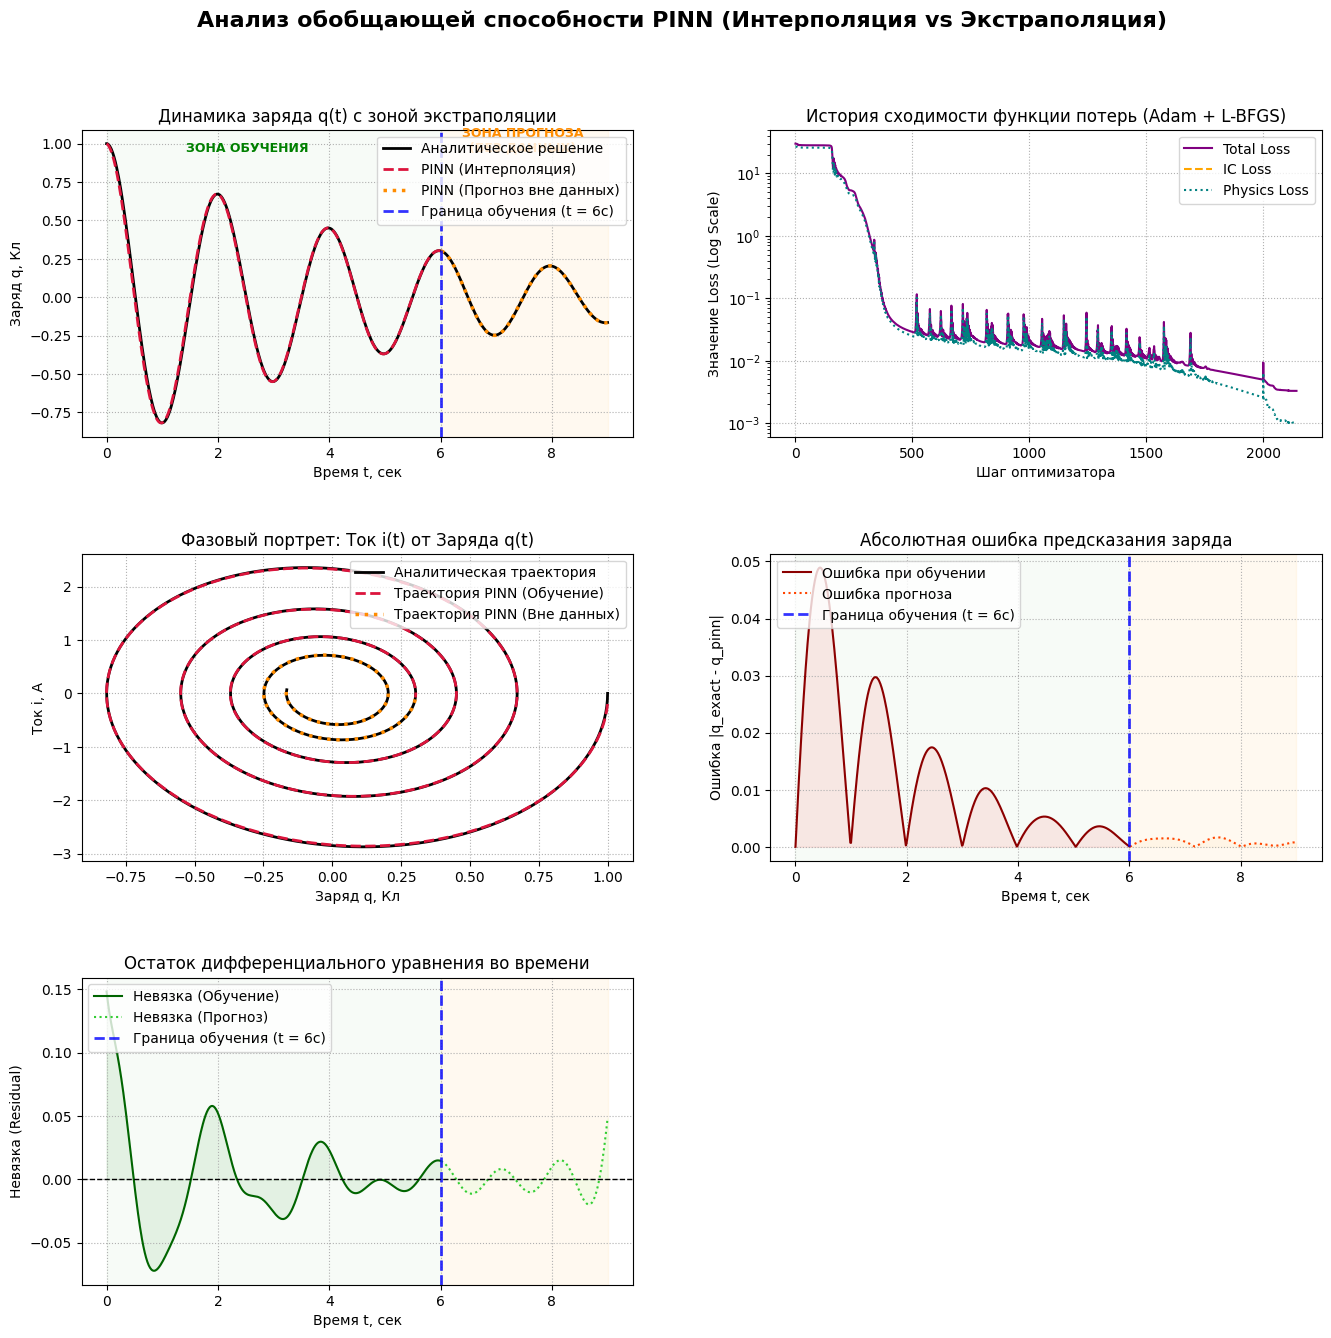

In [ ]:
model.eval()

t_extrap_max = 9.0
t_test = np.linspace(0, t_extrap_max, 750)
t_test_tensor = torch.tensor(t_test, dtype=torch.float32).view(-1, 1).requires_grad_(True).to(device)

q_pinn_tensor = model(t_test_tensor)
i_pinn_tensor, d2q_dt2_pinn_tensor = compute_derivatives(q_pinn_tensor, t_test_tensor)

q_pinn = q_pinn_tensor.detach().cpu().numpy().flatten()
i_pinn = i_pinn_tensor.detach().cpu().numpy().flatten()
residual_test = (L * d2q_dt2_pinn_tensor + R * i_pinn_tensor + (1/C) * q_pinn_tensor).detach().cpu().numpy().flatten()

q_exact = exact_solution(t_test)
i_exact = -gamma * q_exact + Q0 * np.exp(-gamma * t_test) * (-omega_d * np.sin(omega_d * t_test) + gamma * np.cos(omega_d * t_test))

absolute_error = np.abs(q_exact - q_pinn)

train_mask = t_test <= t_max
extrap_mask = t_test > t_max

fig, axs = plt.subplots(3, 2, figsize=(16, 15))
plt.subplots_adjust(hspace=0.38, wspace=0.25)

def highlight_zones(ax):
    ax.axvline(t_max, color='blue', linestyle='--', linewidth=2, alpha=0.8, label='Граница обучения (t = 6с)')
    ax.axvspan(0, t_max, color='green', alpha=0.03)
    ax.axvspan(t_max, t_extrap_max, color='orange', alpha=0.06)

# Динамика заряда
axs[0, 0].plot(t_test, q_exact, label='Аналитическое решение', color='black', linewidth=2)
axs[0, 0].plot(t_test[train_mask], q_pinn[train_mask], '--', label='PINN (Интерполяция)', color='crimson', linewidth=2)
axs[0, 0].plot(t_test[extrap_mask], q_pinn[extrap_mask], ':', label='PINN (Экстраполяция)', color='darkorange', linewidth=2.5)
highlight_zones(axs[0, 0])
axs[0, 0].set_title('Динамика заряда q(t)')
axs[0, 0].set_xlabel('Время, сек')
axs[0, 0].set_ylabel('Заряд, Кл')
axs[0, 0].grid(True, linestyle=':')
axs[0, 0].legend(loc='upper right')
axs[0, 0].text(0.3, 0.93, 'ОБУЧЕНИЕ', transform=axs[0, 0].transAxes, color='green', fontweight='bold', ha='center', fontsize=9)
axs[0, 0].text(0.8, 0.93, 'ПРОГНОЗ', transform=axs[0, 0].transAxes, color='darkorange', fontweight='bold', ha='center', fontsize=9)

# История обучения
axs[0, 1].plot(loss_history_total, label='Total Loss', color='purple', linewidth=1.5)
axs[0, 1].plot(loss_history_ic, label='IC Loss', color='orange', linestyle='--')
axs[0, 1].plot(loss_history_physics, label='Physics Loss', color='teal', linestyle=':')
axs[0, 1].set_yscale('log')
axs[0, 1].set_title('История сходимости')
axs[0, 1].set_xlabel('Шаг оптимизации')
axs[0, 1].set_ylabel('Loss (log шкала)')
axs[0, 1].grid(True, linestyle=':')
axs[0, 1].legend()

# Фазовый портрет
axs[1, 0].plot(q_exact, i_exact, label='Аналитическая траектория', color='black', linewidth=2)
axs[1, 0].plot(q_pinn[train_mask], i_pinn[train_mask], '--', label='PINN (Обучение)', color='crimson', linewidth=2)
axs[1, 0].plot(q_pinn[extrap_mask], i_pinn[extrap_mask], ':', label='PINN (Прогноз)', color='darkorange', linewidth=2.5)
axs[1, 0].set_title('Фазовый портрет i(q)')
axs[1, 0].set_xlabel('Заряд q, Кл')
axs[1, 0].set_ylabel('Ток i, А')
axs[1, 0].grid(True, linestyle=':')
axs[1, 0].legend()

# Абсолютная ошибка
axs[1, 1].plot(t_test[train_mask], absolute_error[train_mask], color='darkred', linewidth=1.5, label='Ошибка обучения')
axs[1, 1].plot(t_test[extrap_mask], absolute_error[extrap_mask], color='orangered', linewidth=1.5, linestyle=':', label='Ошибка прогноза')
axs[1, 1].fill_between(t_test[train_mask], absolute_error[train_mask], color='red', alpha=0.08)
axs[1, 1].fill_between(t_test[extrap_mask], absolute_error[extrap_mask], color='orange', alpha=0.04)
highlight_zones(axs[1, 1])
axs[1, 1].set_title('Абсолютная ошибка q')
axs[1, 1].set_xlabel('Время, сек')
axs[1, 1].set_ylabel('Ошибка')
axs[1, 1].grid(True, linestyle=':')
axs[1, 1].legend(loc='upper left')

# Остаток уравнения
axs[2, 0].plot(t_test[train_mask], residual_test[train_mask], color='darkgreen', linewidth=1.5, label='Невязка (обучение)')
axs[2, 0].plot(t_test[extrap_mask], residual_test[extrap_mask], color='limegreen', linewidth=1.5, linestyle=':', label='Невязка (прогноз)')
axs[2, 0].fill_between(t_test[train_mask], residual_test[train_mask], color='green', alpha=0.08)
axs[2, 0].fill_between(t_test[extrap_mask], residual_test[extrap_mask], color='lime', alpha=0.04)
highlight_zones(axs[2, 0])
axs[2, 0].set_title('Остаток дифференциального уравнения')
axs[2, 0].set_xlabel('Время, сек')
axs[2, 0].set_ylabel('Residual')
axs[2, 0].grid(True, linestyle=':')
axs[2, 0].axhline(0, color='black', linewidth=1, linestyle='--')
axs[2, 0].legend(loc='upper left')

axs[2, 1].axis('off')

plt.suptitle('PINN: интерполяция vs экстраполяция', fontsize=16, fontweight='bold', y=0.96)
plt.show()